# Lesson 03 — Multivariate Regression

<h2 dir="rtl">פרק 1 — פתיחה ורענון</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle as pkl
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

<h2 dir="rtl">פרק 2 — סיפור מנהל הבטיחות</h2>

In [2]:
df = pkl.load(open('data_lesson_3.pkl', 'rb'))
df = df.rename(columns={'guidence': 'guidance', 'invsetment': 'investment'})
df.head()

,guidance,investment,accidents,Factory_num,intercept,Factory
0,0.0,0.00,345,1.0,1,Haifa
1,0.0,1.25,351,2.0,1,Jerusalem
2,0.0,2.50,348,1.0,1,Haifa
3,0.0,3.75,343,2.0,1,Jerusalem
4,0.0,5.00,337,0.0,1,Ariel


In [3]:
np.random.seed(42)
df['training_hours']    = (3.0 * df['guidance']   + np.random.normal(0, 0.3, len(df))).round(2)
df['equipment_count']  = (1.5 * df['investment'] + np.random.normal(0, 0.5, len(df))).round()
df['inspection_count'] = (1.5 * df['guidance']   + 0.3 * df['investment'] + np.random.normal(0, 0.4, len(df))).round()
df.head()

,guidance,investment,accidents,Factory_num,intercept,Factory,training_hours,equipment_count,inspection_count
0,0.0,0.00,345,1.0,1,Haifa,0.15,1.0,-1.0
1,0.0,1.25,351,2.0,1,Jerusalem,-0.04,1.0,1.0
2,0.0,2.50,348,1.0,1,Haifa,0.19,3.0,2.0
3,0.0,3.75,343,2.0,1,Jerusalem,0.46,6.0,2.0
4,0.0,5.00,337,0.0,1,Ariel,-0.07,7.0,1.0


<h2 dir="rtl">פרק 3 — מודל מרובה משתנים</h2>

In [4]:
predictors = ['guidance', 'investment', 'training_hours', 'equipment_count', 'inspection_count']
X_full = sm.add_constant(df[predictors])
model_full = sm.OLS(df['accidents'], X_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2048.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.35e-113
Time:                        03:08:00   Log-Likelihood:                -291.72
No. Observations:                 125   AIC:                             595.4
Df Residuals:                     119   BIC:                             612.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              350.6108      0.550  

<h2 dir="rtl">פרק 4 — מולטיקוליניאריות בעין: correlation</h2>

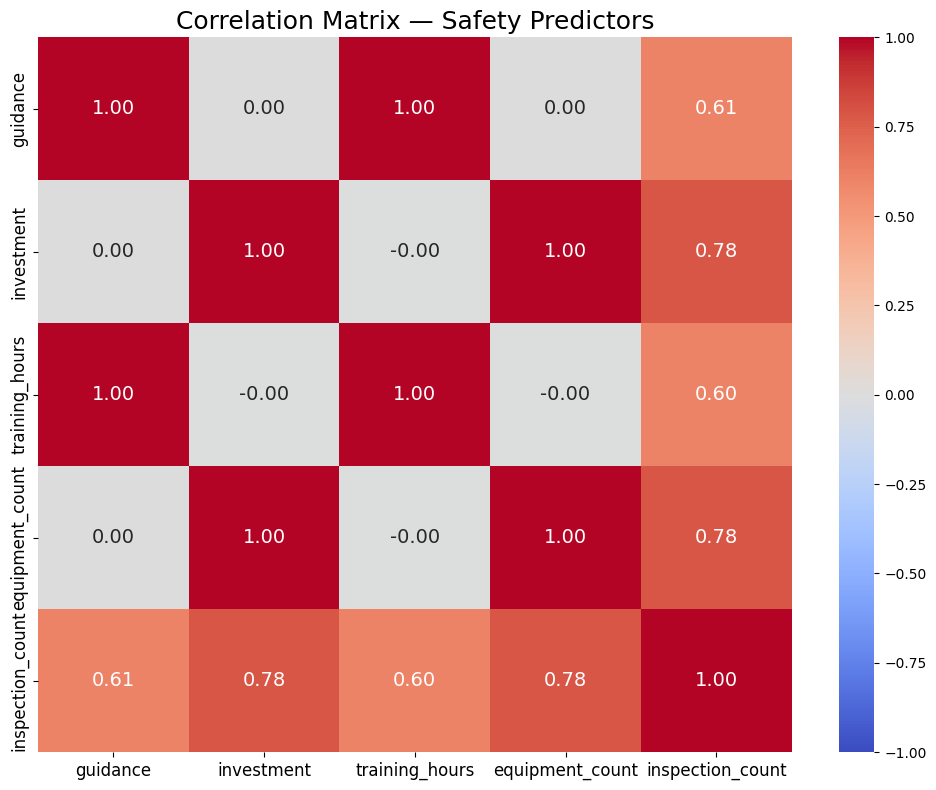

In [5]:
corr_matrix = df[predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, annot_kws={'size': 14})
plt.title('Correlation Matrix — Safety Predictors', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

<h2 dir="rtl">פרק 5 — VIF</h2>

In [6]:
vif_table = pd.DataFrame({
    'Variable': X_full.columns,
    'VIF': [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]
})
vif_table

,Variable,VIF
0,const,5.780333
1,guidance,247.015715
2,investment,571.259608
3,training_hours,242.990861
4,equipment_count,536.638521
5,inspection_count,46.462472


<h2 dir="rtl">פרק 6 — Drop ולהשוות לפני/אחרי</h2>

In [7]:
X_red = sm.add_constant(df[['guidance', 'investment']])
model_red = sm.OLS(df['accidents'], X_red).fit()
print(model_red.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     5113.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          2.29e-118
Time:                        03:08:00   Log-Likelihood:                -293.33
No. Observations:                 125   AIC:                             592.7
Df Residuals:                     122   BIC:                             601.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        350.5840      0.550    637.547      0.0

In [8]:
# Predict for: intercept=1, guidance=3, investment=20
prediction = model_red.predict(np.array([[1, 3, 20]]))
print(f'Predicted accidents: {prediction[0]:.2f}')

Predicted accidents: 279.77


In [9]:
betas_raw = model_red.params[1:]
sY = df['accidents'].std()
sX = df[['guidance', 'investment']].std()
betas_std = betas_raw * sX / sY

std_table = pd.DataFrame({
    'Variable': ['guidance', 'investment'],
    'Raw beta': betas_raw.values,
    'Standardized beta': betas_std.values
})
std_table

,Variable,Raw beta,Standardized beta
0,guidance,-10.272,-0.623737
1,investment,-2.000,-0.774057


<h2 dir="rtl">פרק 7 — חיזוי vs. הסקה</h2>

<h2 dir="rtl">פרק 8 — סגירה ותרגיל</h2>

### Write your answer here.

<div dir="rtl">חשבו ידנית את החיזוי למספר התאונות עבור מפעל עם <code>guidance = 3</code> ו-<code>investment = 20</code>, על בסיס המקדמים מ-<code>model_red.summary()</code>. בדקו שמתקבל אותו ערך כמו ב-<code>model_red.predict()</code> בתא 14.</div>